# CONIFER — a worked vignette

### Compositional, design-aware small-area estimation of forest diameter distributions

**`conifer.DiameterDistribution`** estimates the *diameter distribution* — stem density split
across DBH classes — for small forest areas whose field sample is too thin for a reliable direct
estimate, and it attaches an *honest, valid* statement of uncertainty.

This vignette runs the whole workflow end to end. To keep it readable, the code that **makes the demo
data** and **formats the tables** lives in a small companion file, `forest_demo.py`, next to this
notebook — its full source is in **Appendix B**, and all the underlying math is in **Appendix A**. The
body below stays focused on *what you do with CONIFER* and *what you get back*.

> Package: [`conifer-sae` on PyPI](https://pypi.org/project/conifer-sae/) · source:
> [`IFC-UIDAHO/conifer`](https://github.com/IFC-UIDAHO/conifer) · license: MIT. The data here are
> **synthetic** and exist only to make the walkthrough runnable and its coverage checkable.

## Contents

1. What problem this solves
2. Install
3. How CONIFER thinks (in plain words)
4. **Your data: what goes in** — and how to arrange your own
5. **Fit, and what you get back**
6. Reading the estimate: a forestry summary (QMD)
7. Model-based intervals
8. Design-aware conformal prediction sets
9. Does the set actually cover? An honest check
10. Coherence with a design benchmark (FIA-style)
11. A diagnostic plot
12. The command line
13. Which fit do I need? (ML vs. linear)
14. Session info
15. References
- **Appendix A** — the model, formally (all equations)
- **Appendix B** — how the demo data and tables are made (`forest_demo.py`)

## 1. What problem this solves

Forest inventories increasingly need structure for **small areas** — a stand, a management unit, a
grid cell — where only a handful of field plots land. A direct estimate from a few plots is unbiased
but noisy. **Small-area estimation (SAE)** borrows strength across areas through a model to sharpen
those estimates.

CONIFER targets a specific, hard version of this problem, and three things make it different:

- **The target is a distribution, not a total.** Stem density split across DBH classes is a
  *composition* — non-negative shares that sum to a whole — so per-class models fit independently are
  incoherent. CONIFER models the whole composition.
- **The mean can be nonlinear** in the auxiliary data (LiDAR height/cover metrics, spectral indices,
  climate). A classical *linear* Fay–Herriot is biased where stand structure is complex; CONIFER uses
  a flexible, debiased machine-learned mean that still **reduces exactly to linear Fay–Herriot** when
  you ask it to.
- **The uncertainty is valid, not just plausible.** On top of the model, CONIFER calibrates
  distribution-free **conformal prediction sets** with coverage you can test (we test it in §9).

Nothing off-the-shelf fills this gap: `sae`/`emdi` give area-level Fay–Herriot but no compositional
target and no conformal sets; `MAPIE`/`crepes` give conformal prediction but no small-area borrowing
and no simplex geometry; `rFIA`/`FIESTA` give design-based estimates but do not model or borrow
strength. CONIFER *consumes* design-based FIA estimates as a benchmark rather than competing with them.

## 2. Install

```bash
pip install conifer-sae          # imports as `conifer`
```

To run this notebook you also need `jupyter` and `pandas`, and the companion `forest_demo.py` in the
same folder (it ships in the repo under `docs/vignettes/`). The setup cell below imports CONIFER and
the small display helpers; from here on, cells are short.

In [1]:
import sys; sys.path.insert(0, ".")          # forest_demo.py lives next to this notebook
import numpy as np, pandas as pd, conifer
from forest_demo import (
    make_inventory, dbh_class_table, preview_inputs, covariate_preview,
    describe_outputs, quadratic_mean_diameter, stand_estimate,
    interval_table, show, coverage_report, benchmark_table,
)
print("CONIFER", conifer.__version__, "· ready")

CONIFER 0.1.3 · ready


## 3. How CONIFER thinks (in plain words)

You can use CONIFER without the math, so here is the whole idea in four sentences. **(1)** For each
area it starts from the direct estimate of the class shares and how noisy that estimate is (its
*sampling covariance*, computed from the counts). **(2)** It also predicts the shares from your
auxiliary data with a flexible, cross-fitted machine-learned mean — one built so that, in the linear
case, it is exactly classical Fay–Herriot. **(3)** It then **shrinks** each area's noisy direct
estimate toward that prediction, by an amount that depends on how noisy the direct estimate is: thin
samples borrow more, rich samples borrow less. **(4)** Finally it multiplies the estimated class
*shares* by the estimated *total* to report stems per acre by class, and calibrates a conformal
prediction set around it.

That is the entire method. The precise model — the log-ratio geometry, the shrinkage formula, the
MSE, and the conformal sets — is written out in **Appendix A**.

## 4. Your data: what goes in

CONIFER needs four aligned pieces, one row per small area (here, per forest **stand**):

| you supply | shape | what it is |
|------------|-------|------------|
| `counts` | `(m, K)` | DBH-class tallies — how many trees fell in each diameter class |
| `area_eff` | `(m,)` | effective area sampled in that stand (here, acres) |
| `X` | `(m, p)` | auxiliary covariates (LiDAR/spectral/terrain/climate), one row per stand |
| `groups` *(optional)* | `(m,)` | a stratum label per stand for group-wise (Mondrian) calibration |

`m` = number of stands, `K` = number of DBH classes, `p` = number of covariates. **The rows must line
up** across all four: row *i* of `counts`, `area_eff`, `X`, and `groups` is the same stand.

First, what the **DBH classes** are. `C1…CK` are consecutive diameter bins; in this demo they are six
4-inch classes:

In [2]:
dbh_class_table()          # what C1..C6 mean (diameter range + midpoint, inches)

,DBH range (in),midpoint (in)
class,,
C1,1–5,3.0
C2,5–9,7.0
C3,9–13,11.0
C4,13–17,15.0
C5,17–21,19.0
C6,21–25,23.0


Now the data itself. `make_inventory()` returns a small synthetic inventory (its source is in
Appendix B); all you need to know is that it hands back exactly the pieces in the table above. Here is
what CONIFER actually sees for the first few stands — a stand type, the effective area, and the count
in each DBH class:

In [3]:
D = make_inventory()                      # -> dict with counts, area_eff, X, groups (+ hidden truth)
preview_inputs(D, n=6)                     # the class tallies per stand, as CONIFER receives them

,type,area_ac,C1,C2,C3,C4,C5,C6
stand,,,,,,,,
0,legacy,0.72,77,26,8,4,20,51
1,mixed_conifer,0.96,21,49,3,35,65,61
2,even_aged,0.65,32,4,3,80,0,5
3,mixed_conifer,1.39,6,211,95,6,47,18
4,even_aged,0.79,1,21,70,9,67,20
5,legacy,1.41,279,5,4,15,4,19


…and the matching auxiliary covariates for those stands (standardized LiDAR/spectral/terrain/climate
metrics — use whatever predicts structure in your setting):

In [4]:
covariate_preview(D, n=6)

,VCI,UCI,CanopyRelief,FHD,NDVI,Slope,TWI,ClimateNA
stand,,,,,,,,
0,0.03,1.36,1.22,-0.51,-0.30,-0.53,0.57,-0.06
1,0.75,-1.85,1.57,-0.10,0.68,-0.14,-0.38,0.46
2,0.82,-0.20,-0.15,0.69,-0.87,-1.51,0.39,-0.67
3,-1.92,-0.81,-0.47,-1.19,-1.49,0.04,0.90,-0.23
4,-0.74,0.38,0.72,-0.30,0.54,1.04,-0.21,-0.81
5,0.35,0.25,1.10,-1.28,-0.66,-0.84,-1.73,0.13


**Arranging your own data.** Replace `make_inventory()` with your inventory: build a `counts` matrix
of integer class tallies (stands × classes), a `area_eff` vector of the area each stand's sample
represents, and an `X` matrix of covariates — all row-aligned. That is the entire input contract;
everything below is identical whether the data is real or synthetic.

## 5. Fit, and what you get back

Fitting is one call. Pass the four inputs; get a fitted estimator back.

In [5]:
est = conifer.DiameterDistribution(seed=0).fit(D["counts"], D["area_eff"], D["X"], groups=D["groups"])

The fitted object carries everything you need — the estimate, its parts, and its uncertainty:

In [6]:
describe_outputs(est)          # every result the estimator hands back, with shapes

,shape,what it is
attribute,,
s_hat_,"(300, 6)",stems/acre by DBH class — the estimate
N_hat_,"(300,)",total stems/acre per stand
p_hat_,"(300, 6)","class shares (composition), rows sum to 1"
s_var_,"(300, 6)",variance of s_hat_ (delta method)
Su_,"(5, 5)",estimated area random-effect covariance
mse_theta_,"(300, 5, 5)",2nd-order MSE on the log-ratio scale


The headline is `s_hat_` (stems/acre by DBH class). A couple of quick reads:

In [7]:
show(est.s_hat_.mean(0), labels=[f"C{k+1}" for k in range(D["K"])], name="mean stems/acre")

C1    39.16
C2    37.30
C3    57.20
C4    43.46
C5    48.31
C6    31.60
Name: mean stems/acre, dtype: float64

In [8]:
print("total stems/acre (mean over stands):", round(float(est.N_hat_.mean()), 1))
print("class shares of stand 0 sum to     :", round(float(est.p_hat_[0].sum()), 3))

total stems/acre (mean over stands): 257.0
class shares of stand 0 sum to     : 1.0


## 6. Reading the estimate: a forestry summary

Because the estimate is a whole distribution, any stand-level summary follows from it. Here is the
per-stand picture — stems/acre by class, the total, and **quadratic mean diameter (QMD)**, all from
one helper:

In [9]:
stand_estimate(est, D, stands=range(5))    # per-stand: classes, total N/ac, QMD (inches)

,type,C1,C2,C3,C4,C5,C6,N/ac,QMD_in
stand,,,,,,,,,
0,legacy,74.0,40.7,25.2,16.4,50.9,51.9,259.0,14.6
1,mixed_conifer,12.4,44.5,2.5,114.2,26.8,42.4,243.0,15.8
2,even_aged,97.7,19.0,10.0,60.5,0.5,8.5,196.0,10.4
3,mixed_conifer,12.2,28.1,203.1,5.5,7.1,18.0,274.0,12.0
4,even_aged,4.7,38.9,50.2,18.7,74.1,53.0,240.0,16.7


`quadratic_mean_diameter()` is just a function of `s_hat_` and the class midpoints (formula in
Appendix A). `show()` gives a quick distribution summary across all stands:

In [10]:
qmd = quadratic_mean_diameter(est, D["edges"])
show(qmd, name="QMD (in)")                  # summary across all stands

,QMD (in)
count,300.00
mean,14.15
std,2.18
min,3.25
25%,12.79
50%,14.35
75%,15.76
max,19.12


## 7. Model-based intervals

`class_intervals(z)` gives the classic model-based SAE interval from the delta-method variance
`s_var_` (fast, but its coverage leans on the model). §8 adds a distribution-free alternative.

In [11]:
lo, hi = est.class_intervals(z=1.645)                 # ~90% Gaussian working interval
interval_table(est, lo, hi, D, stand=0, label="param")

,estimate,param_lo,param_hi
class,,,
C1,74.0,21.4,126.5
C2,40.7,3.1,78.4
C3,25.2,0.8,49.5
C4,16.4,3.8,29.0
C5,50.9,0.8,100.9
C6,51.9,27.2,76.6


## 8. Design-aware conformal prediction sets

Split-conformal calibration turns the model into *valid* prediction sets: hold out half the stands to
calibrate, then read off a threshold. CONIFER offers three flavours — **per-class** intervals, a
**joint $L_\infty$ band** (simultaneous over classes), and a tighter **min-volume ellipsoid** in
Aitchison (simplex) geometry — all calibrated within `groups`.

In [12]:
rng = np.random.default_rng(0); perm = rng.permutation(D["m"])
cal, test = perm[:150], perm[150:]

# joint L-inf band (simultaneous over the K classes)
est.conformalize(D["s_true"], cal, joint=True, mode="maxscore", alpha=0.10)
lo_box, hi_box = est.predict_interval(joint=True)

# tighter: minimum-volume ellipsoid on the simplex (Aitchison / clr geometry)
est.conformalize(D["s_true"], cal, joint=True, mode="min_vol", geom="ilr", alpha=0.10)
lo_ell, hi_ell = est.predict_interval(joint=True)

# a representative test stand: the one with the median total stem density
stand = int(test[np.argsort(est.s_hat_[test].sum(1))[len(test) // 2]])
tbl = interval_table(est, lo_box, hi_box, D, stand, label="Linf")
tbl["ellipsoid_lo"] = np.round(np.clip(lo_ell[stand], 0, None), 1)
tbl["ellipsoid_hi"] = np.round(hi_ell[stand], 1)
print(f"stand {stand} — 90% joint conformal sets, two geometries")
tbl

stand 69 — 90% joint conformal sets, two geometries


,estimate,Linf_lo,Linf_hi,ellipsoid_lo,ellipsoid_hi
class,,,,,
C1,38.5,0.0,92.4,13.6,91.7
C2,29.5,0.0,66.2,9.5,78.7
C3,80.8,0.0,164.3,30.1,158.1
C4,11.1,0.0,28.4,4.4,27.1
C5,59.4,4.6,114.3,21.5,128.3
C6,40.8,3.2,78.4,25.5,62.7


## 9. Does the set actually cover? An honest check

Conformal coverage is a property *on average over calibration/test splits*, so we check it that way:
repeat the split many times and average the fraction of held-out stands whose **true** stem density
lands in the set. The demo kept `s_true`, so we can. We expect ≈ **0.90** for the 90% sets.

In [13]:
coverage_report(D, est, reps=50)            # honest repeated-split coverage (source in Appendix B)

,coverage,sd,nominal
per-class marginal,0.909,0.015,0.9
joint L-inf band,0.913,0.026,0.9
joint min-volume ellipsoid,0.861,0.042,0.9


The $L_\infty$ band and the per-class intervals sit on the nominal 0.90 — distribution-free validity,
as advertised. The min-volume ellipsoid is **tighter** (smaller sets) and on this small `m = 300` toy
runs a little under nominal; it tightens toward 0.90 with more calibration data. So: $L_\infty$ when
calibration is scarce, ellipsoid when it is plentiful. (The paper reports tested joint coverage of
**0.944** on the real St. Joe study.)

## 10. Coherence with a design benchmark (FIA-style)

SAE estimates should agree, in aggregate, with the trusted design totals they roll up to.
`benchmark(totals)` applies the Bell–Datta–Ghosh adjustment so the population-weighted mean of the
small-area estimates reproduces each class total exactly.

In [14]:
totals = (D["counts"] / D["area_eff"][:, None]).mean(0)      # design-direct class totals (target)
est.benchmark(totals)
benchmark_table(est, totals, D)

,target,model_before,benchmarked_after
class,,,
C1,39.9,39.2,39.9
C2,40.8,37.3,40.8
C3,57.7,57.2,57.7
C4,41.9,43.5,41.9
C5,49.0,48.3,49.0
C6,27.8,31.6,27.8


## 11. A diagnostic plot

`conifer.plots.plot_estimate` draws one stand's diameter distribution with the conformal set as
whiskers (call `conformalize` first so the whiskers are the valid set).

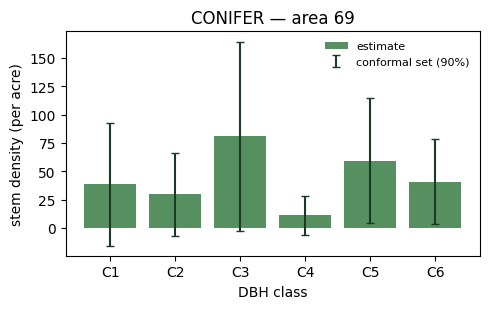

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
from conifer.plots import plot_estimate

est.conformalize(D["s_true"], cal, joint=True, mode="maxscore", alpha=0.10)
ax = plot_estimate(est, area_index=stand, joint=True, alpha=0.10)
plt.tight_layout(); plt.show()

## 12. The command line

No Python needed for a basic fit — point the `conifer` CLI at three aligned CSV matrices:

```bash
conifer fit --counts counts.csv --area area.csv --aux aux.csv --out s_hat.csv
```

Run here on the demo data (paths are machine-specific and trimmed from the output):

In [16]:
import subprocess, tempfile, os
tmp = tempfile.mkdtemp()
np.savetxt(os.path.join(tmp, "counts.csv"), D["counts"], delimiter=",")
np.savetxt(os.path.join(tmp, "area.csv"),   D["area_eff"], delimiter=",")
np.savetxt(os.path.join(tmp, "aux.csv"),    D["X"], delimiter=",")
proc = subprocess.run([sys.executable, "-m", "conifer.cli", "fit",
    "--counts", os.path.join(tmp, "counts.csv"), "--area", os.path.join(tmp, "area.csv"),
    "--aux", os.path.join(tmp, "aux.csv"), "--out", os.path.join(tmp, "s_hat.csv"), "--seed", "0"],
    capture_output=True, text=True, cwd=tmp)
for line in proc.stdout.strip().splitlines():
    print(line.split(" -> ")[0] if line.startswith("CONIFER: fit") else line)
print("wrote s_hat.csv ->", np.loadtxt(os.path.join(tmp, "s_hat.csv"), delimiter=",", skiprows=1).shape)

CONIFER: fit 300 areas x 6 classes
mean stem density by class: [39.16, 37.3, 57.2, 43.46, 48.31, 31.6]
wrote s_hat.csv -> (300, 6)


## 13. Which fit do I need? (ML vs. linear)

The default mean is a flexible, cross-fitted ML mean (`mean_mode="ml"`). Set `mean_mode="linear"` and
CONIFER becomes an ordinary compositional **linear Fay–Herriot** — the classical baseline. How to
choose: **fit both and compare.** If they largely agree, the structure is linear and the simpler model
is fine; if they diverge, the ML mean is capturing curvature the linear fit misses — prefer the
default.

In [17]:
est_lin = conifer.DiameterDistribution(seed=0, mean_mode="linear").fit(
    D["counts"], D["area_eff"], D["X"], groups=D["groups"])

# where does the flexible mean disagree with the linear one? group by stand complexity.
gap = pd.DataFrame(
    {"mean |ML − linear| (stems/acre/cell)":
        [np.abs(est.s_hat_[D["groups"] == g] - est_lin.s_hat_[D["groups"] == g]).mean()
         for g in range(3)]},
    index=D["type_names"]).round(1).rename_axis("stand type")
print("The two fits agree on simple stands and diverge on curved ones —")
print("the divergence is the ML mean doing work the linear fit cannot:")
gap

The two fits agree on simple stands and diverge on curved ones —
the divergence is the ML mean doing work the linear fit cannot:


,mean |ML − linear| (stems/acre/cell)
stand type,
even_aged,2.8
legacy,3.3
mixed_conifer,3.9


## 14. Session info

Everything above is seeded — re-running top to bottom reproduces the numbers exactly.

In [18]:
import scipy, sklearn, matplotlib
print("Python    :", sys.version.split()[0])
print("conifer   :", conifer.__version__)
for m in (np, scipy, sklearn, pd, matplotlib):
    print(f"{m.__name__:<10}:", m.__version__)

Python    : 3.10.12
conifer   : 0.1.3
numpy     : 2.2.6
scipy     : 1.15.3
sklearn   : 1.7.2
pandas    : 2.3.3
matplotlib: 3.10.9


## 15. References

**Method.** CONIFER is *a debiased-ML compositional Fay–Herriot with design-aware simplex conformal
prediction sets for forest diameter distributions.* Cite it via the
[`CITATION.cff`](https://github.com/IFC-UIDAHO/conifer/blob/main/CITATION.cff) in the repository.

**Background.** Rao & Molina, *Small Area Estimation*, 2nd ed. (2015); Fay & Herriot (1979, *JASA*);
the R packages `sae` and `emdi`; Vovk, Gammerman & Shafer, *Algorithmic Learning in a Random World*
(2005) and the Python packages `MAPIE`, `crepes` for conformal prediction; Aitchison, *The Statistical
Analysis of Compositional Data* (1986); the R packages `rFIA`, `FIESTA` for design-based FIA estimation.

## Appendix A — the model, formally

For area $i$ with DBH classes $k = 1,\dots,K$, write the class shares as a composition $p_i$ (a vector
of non-negative shares summing to 1) and the total stem density as $N_i$. The target is

$$s_{ik} \;=\; N_i \, p_{ik}.$$

**Composition (area-level Fay–Herriot in log-ratio coordinates).** Let $y_i$ be the additive
log-ratio of the direct share estimate. The area-level model is

$$y_i \;=\; \theta_i + e_i, \qquad e_i \sim (0,\, D_i),$$

$$\theta_i \;=\; \mu(x_i) + u_i, \qquad u_i \sim (0,\, \Sigma_u),$$

where $D_i$ is the **design sampling covariance** of the direct estimate (an analytic
Dirichlet–multinomial from the class counts), $\mu(\cdot)$ is the mean function of the auxiliary data
$x_i$, and $u_i$ is a correlated area random effect.

**Shrinkage (empirical best predictor).** The estimate shrinks the direct value toward the modelled
mean by the gain $G_i$:

$$\hat\theta_i \;=\; \hat\mu(x_i) + G_i\,\bigl(y_i - \hat\mu(x_i)\bigr), \qquad
G_i \;=\; \Sigma_u\,(\Sigma_u + D_i)^{-1}.$$

Thin samples (large $D_i$) give small $G_i$ and borrow more from the model; rich samples borrow less.
$\hat\mu$ is a cross-fitted, one-step-debiased machine-learned mean built to nest the linear fit; when
$\hat\mu$ is linear this is ordinary multivariate Fay–Herriot.

**Total and back-transform.** $N_i$ is estimated by a log-total Fay–Herriot (with a structural-zero
hurdle for genuinely absent classes); inverting the log-ratio gives $\hat p_i$, and
$\hat s_{ik} = \hat N_i\,\hat p_{ik}$, with a delta-method covariance `s_var_`.

**Quadratic mean diameter.** With class midpoints $d_k$,

$$\mathrm{QMD}_i \;=\; \sqrt{\dfrac{\sum_k \hat s_{ik}\, d_k^2}{\sum_k \hat s_{ik}}}.$$

**Conformal sets.** On a held-out calibration split, a nonconformity score is computed per area
(per-class, an $L_\infty$ max-score, or a Mahalanobis distance for the ellipsoid) and its
$(1-\alpha)$ quantile becomes the set radius, Mondrian by `groups`. The `geom="ilr"` option scores in
Aitchison (clr) geometry, so the joint set is basis-equivariant on the simplex. Coverage is
distribution-free given exchangeability.

## Appendix B — how the demo data and tables are made

Everything the body imported from `forest_demo.py` is printed below verbatim: the synthetic-inventory
generator (`make_inventory`, with the fixed nonlinear structural map and the known truth `s_true`) and
the small display helpers (`preview_inputs`, `describe_outputs`, `stand_estimate`, `coverage_report`,
…). None of it is part of CONIFER — it is only here so the walkthrough is fully reproducible and
nothing is hidden.

In [19]:
print(open("forest_demo.py").read())

"""forest_demo.py — data + display helpers for the CONIFER getting-started vignette.

None of this is part of CONIFER. It only (a) synthesises a small, reproducible forest
inventory with a KNOWN truth so the vignette can check coverage honestly, and (b) formats
CONIFER's outputs as tidy tables so the notebook cells stay one-liners. The full source is
printed in Appendix B of the vignette, so nothing here is hidden — just kept out of the way.

Units follow US inventory convention: DBH (diameter at breast height) in INCHES; stem
density in stems per ACRE.
"""
from __future__ import annotations
import numpy as np
import pandas as pd

# Six 4-inch DBH classes from 1" to 25".
DBH_EDGES = np.array([1, 5, 9, 13, 17, 21, 25], dtype=float)
COVARIATES = ["VCI", "UCI", "CanopyRelief", "FHD", "NDVI", "Slope", "TWI", "ClimateNA"]
STAND_TYPES = np.array(["even_aged", "legacy", "mixed_conifer"])


def _clabels(K):
    return [f"C{k+1}" for k in range(K)]


def dbh_class_table(edges=DBH_EDGES):
    ""